# 成员推理攻击 (Membership Inference Attack)

## 攻击场景

设想以下情境：一家医院用患者数据训练了一个疾病预测模型，并对外开放 API。攻击者想知道「张三是否在这家医院看过病」——他只需要：

1. 构造一条与张三特征相同的输入，查询模型的预测置信度；
2. 如果置信度**异常高**，说明这条数据很可能在训练集中（即张三确实看过病）。

这就是**成员推理攻击**：通过观察模型输出，推断某条数据是否参与了模型训练。

## 本 Notebook 的实验设计

| 步骤 | 做什么 | 为什么 |
|------|--------|--------|
| 训练目标模型 | 在 CIFAR-10（5 类）上训练 CNN | 制造过拟合，产生成员信号 |
| 提取攻击特征 | 对每条样本提取 [置信度, 熵, 损失] | 这些统计量在 member/non-member 间有差异 |
| 阈值攻击 | 用单一阈值分类 | 最简单的攻击基线 |
| MLP 攻击 | 训练二分类器 | 学习更复杂的成员判定边界 |
| 可视化 | 置信度直方图 + ROC 曲线 | 直观展示攻击有效性

In [1]:
# 导入依赖库
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset, Subset
from sklearn.metrics import roc_curve, auc, accuracy_score
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 固定随机种子，便于复现
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


## 1. 数据准备：CIFAR-10（仅 5 类）

仅使用前 5 个类别（airplane, automobile, bird, cat, deer），放大模型过拟合程度。类别越少，模型越容易死记硬背训练样本，成员信号越强。

In [2]:
# 加载本地 CIFAR-10 数据集，仅使用前 5 个类别以放大成员/非成员信号
CIFAR10_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
SELECTED_CLASSES = [0, 1, 2, 3, 4]

transform = transforms.Compose([
    transforms.ToTensor(),  # 将像素归一化到 [0, 1]
])

train_set_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=False, transform=transform)
test_set_full = torchvision.datasets.CIFAR10(root='./data', train=False, download=False, transform=transform)

class FilteredDataset(Dataset):
    '''保留指定类别，并将标签重新映射为 0~len(classes)-1'''
    def __init__(self, dataset, classes):
        self.dataset = dataset
        self.classes = classes
        self.remap = {c: i for i, c in enumerate(classes)}
        self.indices = [i for i in range(len(dataset)) if dataset[i][1] in classes]

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        x, y = self.dataset[self.indices[idx]]
        return x, self.remap[y]

train_set = FilteredDataset(train_set_full, SELECTED_CLASSES)
test_set = FilteredDataset(test_set_full, SELECTED_CLASSES)
print(f"Train samples: {len(train_set)}, Test samples: {len(test_set)}")
print(f"Selected classes: {[CIFAR10_NAMES[c] for c in SELECTED_CLASSES]}")


Train samples: 25000, Test samples: 5000
Selected classes: ['airplane', 'automobile', 'bird', 'cat', 'deer']


## 2. 目标模型

使用与对抗攻击实验相同的 SimpleCNN。这个模型容量有限（~100K 参数），在 5 类 CIFAR-10 上容易过拟合——正是成员推理攻击的理想目标。

In [3]:
# 定义简单的 CNN 目标模型
class SimpleCNN(nn.Module):
    '''用于 CIFAR-10 的轻量 CNN'''
    def __init__(self, num_classes=5):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.max_pool2d(x, 2)
        x = F.relu(self.conv2(x))
        x = F.max_pool2d(x, 2)
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


In [4]:
# 训练与评估工具函数

def train_model(model, loader, epochs=15, lr=0.001):
    '''训练目标分类模型'''
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()
    for epoch in range(epochs):
        running_loss = 0.0
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
        avg_loss = running_loss / len(loader.dataset)
        print(f"Epoch {epoch+1}/{epochs}, loss: {avg_loss:.4f}")
    return model


def evaluate(model, loader):
    '''评估模型分类准确率'''
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            preds = model(x).argmax(dim=1)
            correct += (preds == y).sum().item()
            total += y.size(0)
    return correct / total if total > 0 else 0.0


## 3. 训练目标模型并观察泛化差距

**关键指标：泛化差距（Generalization Gap）= 训练准确率 − 测试准确率**

这是成员推理攻击的核心弹药：
- 差距 **> 0.2**：模型显著过拟合，训练样本的置信度远高于测试样本 → 攻击容易成功
- 差距 **≈ 0**：模型泛化良好，无法区分成员/非成员 → 攻击无效

你可以尝试增减训练轮数，观察差距如何变化。

In [5]:
# 训练目标模型（约 15 个 epoch）
BATCH_SIZE = 64
EPOCHS = 15

train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_set, batch_size=BATCH_SIZE, shuffle=False)

target_model = SimpleCNN(num_classes=len(SELECTED_CLASSES)).to(device)
target_model = train_model(target_model, train_loader, epochs=EPOCHS)


Epoch 1/15, loss: 1.0587
Epoch 2/15, loss: 0.8542
Epoch 3/15, loss: 0.7773
Epoch 4/15, loss: 0.7148
Epoch 5/15, loss: 0.6619
Epoch 6/15, loss: 0.6117
Epoch 7/15, loss: 0.5742
Epoch 8/15, loss: 0.5376
Epoch 9/15, loss: 0.5007
Epoch 10/15, loss: 0.4732
Epoch 11/15, loss: 0.4399
Epoch 12/15, loss: 0.4064
Epoch 13/15, loss: 0.3717
Epoch 14/15, loss: 0.3465
Epoch 15/15, loss: 0.3124


In [6]:
# 观察目标模型的训练/测试准确率，越大的差距说明模型越容易受到成员推理攻击
train_acc = evaluate(target_model, train_loader)
test_acc = evaluate(target_model, test_loader)
print(f"Target train accuracy: {train_acc:.4f}")
print(f"Target test accuracy:  {test_acc:.4f}")
print(f"Generalization gap:    {train_acc - test_acc:.4f}")


Target train accuracy: 0.9054
Target test accuracy:  0.7778
Generalization gap:    0.1276


## 4. 构建攻击数据集

### 攻击者的视角

攻击者只能通过 **API 查询模型**（黑盒），不能访问模型参数或训练数据。但他可以观察到模型对每条输入的**输出概率分布**。

### 攻击特征：模型「泄露」了什么？

对每条输入样本，攻击者提取三个统计量：

| 特征 | 含义 | member 倾向 | non-member 倾向 |
|------|------|------------|-----------------|
| **最大置信度** | max(softmax) | **高**（模型见过，很确定） | 低（模型不确定） |
| **预测熵** | -Σ p·log(p) | **低**（分布尖锐） | 高（分布平坦） |
| **交叉熵损失** | -log(p_true) | **低**（预测正确且自信） | 高（预测错误或不自信） |

这三个特征从不同角度捕获同一个信号：**模型对训练数据的「记忆效应」**。

In [7]:
# 构建成员推理攻击数据集：从训练集（member）和测试集（non-member）各采样相同数量样本

def build_attack_dataset(model, member_dataset, non_member_dataset,
                         member_size=5000, non_member_size=5000, batch_size=64):
    '''提取每个样本的攻击特征：最大置信度、预测熵、真实标签下的交叉熵损失'''
    model.eval()
    member_indices = np.random.choice(len(member_dataset), member_size, replace=False)
    non_member_indices = np.random.choice(len(non_member_dataset), non_member_size, replace=False)

    features, labels = [], []
    datasets = [member_dataset, non_member_dataset]
    indices_list = [member_indices, non_member_indices]
    for ds, idx, label in zip(datasets, indices_list, [1, 0]):
        subset = Subset(ds, idx)
        loader = DataLoader(subset, batch_size=batch_size, shuffle=False)
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            with torch.no_grad():
                logits = model(x)
                probs = F.softmax(logits, dim=1)
                confidence = probs.max(dim=1)[0].cpu().numpy()
                entropy = (-probs * torch.log(probs + 1e-12)).sum(dim=1).cpu().numpy()
                loss = F.cross_entropy(logits, y, reduction='none').cpu().numpy()
            features.append(np.stack([confidence, entropy, loss], axis=1))
            labels.append(np.full(confidence.shape, label))

    features = np.concatenate(features, axis=0)
    labels = np.concatenate(labels, axis=0)
    return features, labels

features, labels = build_attack_dataset(target_model, train_set, test_set)
print("Feature shape:", features.shape, "Label shape:", labels.shape)


Feature shape: (10000, 3) Label shape: (10000,)


## 5. 攻击一：基于阈值的简单攻击

### 原理

如果「置信度 > 阈值 → member」的判定准确率显著超过 50%，说明模型泄露了成员信息。

### 解读结果

- **攻击准确率 > 60%**：攻击有效，模型存在隐私泄露
- **AUC ≈ 0.5**：模型没有泄露可利用的信号（理想情况）
- **AUC > 0.7**：攻击很强，隐私风险严重

### 防御启示

差分隐私训练（Notebook 15）通过给梯度加噪声，缩小训练/测试置信度差距，从而降低 AUC。

In [8]:
# 先将攻击数据分为验证集和测试集，避免阈值过拟合
from sklearn.model_selection import train_test_split as tts_split
X_thresh, X_thresh_test, y_thresh, y_thresh_test = tts_split(
    features, labels, test_size=0.5, random_state=42, stratify=labels)

# 1) 基于置信度阈值的攻击：置信度越高，越可能是训练样本

# 1) 基于置信度阈值的攻击：置信度越高，越可能是训练样本

fpr, tpr, thresholds = roc_curve(y_thresh, X_thresh[:, 0])  # 用最大置信度作为攻击分数
roc_auc = auc(fpr, tpr)

# 使用 Youden 指数选择最佳阈值
best_idx = np.argmax(tpr - fpr)
best_threshold = thresholds[best_idx]
threshold_preds = (X_thresh_test[:, 0] >= best_threshold).astype(int)
threshold_acc = accuracy_score(y_thresh_test, threshold_preds)

print(f"Threshold attack accuracy: {threshold_acc:.4f}")
print(f"Threshold attack AUC:      {roc_auc:.4f}")
print(f"Best threshold:            {best_threshold:.4f}")


Threshold attack accuracy: 0.5280
Threshold attack AUC:      0.5472
Best threshold:            0.8623


## 6. 攻击二：训练 MLP 攻击模型

### 原理

阈值攻击只用了一个特征（置信度）。MLP 攻击模型同时利用 [置信度, 熵, 损失] 三个特征，学习更复杂的判定边界。

### 对比

| 方法 | 优势 | 劣势 |
|------|------|------|
| 阈值攻击 | 简单、无需训练、可解释 | 只用一个特征 |
| MLP 攻击 | 多特征组合，通常更准 | 需要训练攻击模型 |

### 现实威胁

在真实场景中，攻击者可以通过以下方式获取攻击模型的训练数据：
- 使用与目标模型相同架构训练「shadow model」
- 利用公开数据集模拟 member/non-member

In [9]:
# 2) 训练一个二分类攻击模型（2 层 MLP），输入为 [confidence, entropy, loss]

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.3, random_state=SEED, stratify=labels
)

class AttackMLP(nn.Module):
    '''成员推理攻击模型：根据预测统计量推断成员身份'''
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 16),
            nn.ReLU(),
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).squeeze(1)

attack_model = AttackMLP().to(device)
optimizer = optim.Adam(attack_model.parameters(), lr=0.001)
criterion = nn.BCELoss()

X_train_t = torch.tensor(X_train, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train, dtype=torch.float32).to(device)
X_test_t = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_t = torch.tensor(y_test, dtype=torch.float32).to(device)

train_ds = torch.utils.data.TensorDataset(X_train_t, y_train_t)
train_loader_attack = DataLoader(train_ds, batch_size=64, shuffle=True)

for epoch in range(20):
    attack_model.train()
    for xb, yb in train_loader_attack:
        optimizer.zero_grad()
        pred = attack_model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()

attack_model.eval()
with torch.no_grad():
    pred_test = attack_model(X_test_t).cpu().numpy()
    pred_label = (pred_test >= 0.5).astype(int)
    learned_acc = accuracy_score(y_test, pred_label)
    fpr_l, tpr_l, _ = roc_curve(y_test, pred_test)
    learned_auc = auc(fpr_l, tpr_l)

print(f"Learned attack accuracy: {learned_acc:.4f}")
print(f"Learned attack AUC:      {learned_auc:.4f}")


Learned attack accuracy: 0.5630
Learned attack AUC:      0.5871


## 7. 可视化解读

### 左图：置信度直方图

- **红色（Member）**分布偏右——模型对训练数据置信度高
- **蓝色（Non-member）**分布偏左——模型对测试数据置信度低
- **重叠区域**：攻击者无法区分的灰色地带。重叠越少，攻击越容易

### 右图：ROC 曲线

- 曲线越**远离对角线**（向左上角弯曲），攻击越有效
- AUC = 曲线下面积，0.5 = 随机猜测，1.0 = 完美攻击
- 虚线 = 随机猜测基线（50%）

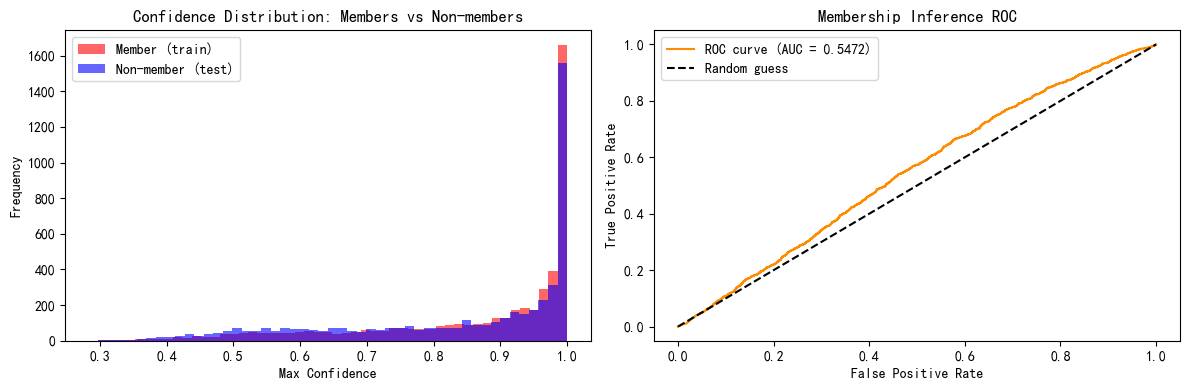

In [10]:
# 可视化：成员与非成员的置信度分布 + ROC 曲线

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
member_conf = features[labels == 1, 0]
non_member_conf = features[labels == 0, 0]
plt.hist(member_conf, bins=50, alpha=0.6, label='Member (train)', color='red')
plt.hist(non_member_conf, bins=50, alpha=0.6, label='Non-member (test)', color='blue')
plt.xlabel('Max Confidence')
plt.ylabel('Frequency')
plt.title('Confidence Distribution: Members vs Non-members')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.4f})', color='darkorange')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Membership Inference ROC')
plt.legend()

plt.tight_layout()
plt.show()


## 8. 结论与防御

### 攻击成功的条件

成员推理攻击**不是万能的**——它只在模型过拟合时有效：

| 条件 | 攻击效果 |
|------|---------|
| 泛化差距大（train >> test） | ✅ 攻击准确率高 |
| 泛化差距小（train ≈ test） | ❌ 攻击接近随机猜测 |
| 模型使用了 DP 训练 | ❌ 噪声抹平了成员信号 |

### 防御方法

| 防御 | 原理 | 代价 |
|------|------|------|
| **差分隐私训练**（→ Notebook 15） | 给梯度加高斯噪声，限制单个样本的影响 | 准确率下降 |
| **正则化** | Dropout / Weight Decay / Early Stopping 减少过拟合 | 模型容量受限 |
| **置信度压缩** | 只返回 top-1 标签，或降低 softmax 温度 | API 可用性下降 |

### 与其他 Notebook 的联系

- **← Notebook 15（DP-SGD）**：DP 是最有效的防御，直接缩小泛化差距
- **← Notebook 12（联邦学习）**：FL 的全局模型仍然可以被成员推理攻击——数据「不出本地」不等于「模型记不住」
- **→ Notebook 17（模型窃取）**：成员推理是「你的数据在我的模型里吗？」，模型窃取是「我能不能复制你的模型？」——两者都是黑盒隐私攻击